In [1]:
import jax
import jax.numpy as jnp
import immrax as irx
from immrax.taylor import BasicTMFlowpipeGenerator
import matplotlib.pyplot as plt


In [2]:
class CVDP(irx.System):
    def __init__(self, mu=1.0):
        self.evolution = "continuous"
        self.xlen = 5
        self.mu = mu

    def f(self, t, x):
        x1, y1, x2, y2, b = x
        return jnp.array(
            [
                y1,
                self.mu * (1 - x1**2) * y1 + b * (x2 - x1) - x1,
                y2,
                self.mu * (1 - x2**2) * y2 + b * (x1 - x2) - x2,
                0.0,
            ]
        )


In [3]:
sys = CVDP(mu=1.0)
t0 = 0.0
tf = 7.0
ix0 = irx.icentpert([1.4, 2.4, 1.4, 2.4, 2.0], [0.15, 0.05, 0.15, 0.05, 1.0])
print(ix0)
tmx = irx.taylor_model_identity(ix0, order=1)

fpg = BasicTMFlowpipeGenerator(sys)
dt = 0.005

delta = 1e-5
eps = 1e-3


@jax.jit
def gen_flowpipe(t0, tf, tmx, dt, delta, eps):
    return fpg.generate_flowpipe(
        t0, tf, tmx, dt_max=dt, t_order=3, delta=delta, eps=eps
    )


[1.25      2.3500001 1.25      2.3500001 1.       ] <= x <= [1.55 2.45 1.55 2.45 3.  ]


In [4]:
fp, times = irx.utils.run_times(10, gen_flowpipe, t0, tf, tmx, dt, delta, eps)

print(f"nsteps: {fp.nsteps}, success: {fp.success}, med time {jnp.median(times)}")

nsteps: 1400, success: True, med time 0.19627586007118225


In [16]:
print(fp[0].domain)
hulls = fp.interval_hulls()[:fp.nsteps]
print(hulls.shape)

# Verify the specification
def spec (x) :
    return jnp.logical_or(x.upper[1] > 2.75, x.upper[3] > 2.75)

S = not jnp.any(jax.vmap(spec)(hulls)) 
if S :
    print('Verified the specification')
else :
    print('Did not verify the specification')

(0.0 <= x <= 0.005, [1.25      2.3500001 1.25      2.3500001 1.       ] <= x <= [1.55 2.45 1.55 2.45 3.  ])
(1400, 5)
Verified the specification


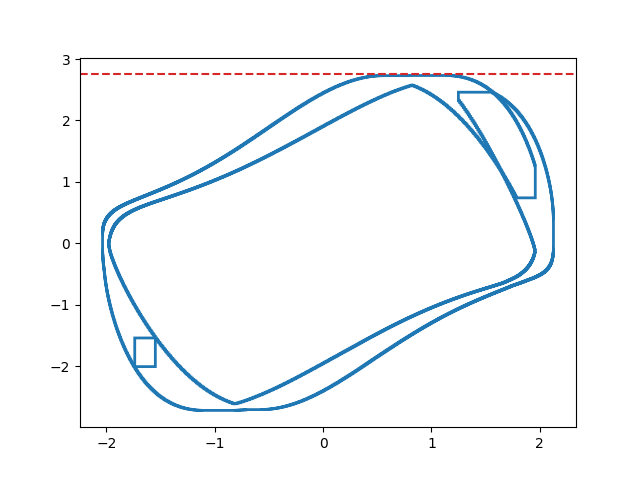

All checks passed.


In [19]:
%matplotlib widget

fig, ax = plt.subplots()

# Draw a line at y = 2.75
ax.axhline(y=2.75, color="tab:red", linestyle="--")

# irx.utils.draw_iarrays(ax, hulls)
irx.utils.draw_iarrays(ax, hulls[:fp.nsteps//2])
irx.utils.draw_iarrays(ax, hulls[fp.nsteps//2:])


# Check __call__ against exact solution x(t) = [-2*cos(t), 2*sin(t)]
# test_times = [0.05, 0.25, 0.5, 0.75, 0.99]
# test_times = jnp.linspace(t0, tf, 100)
# for t in test_times:
#     spatial_tm = fp(t)
#     irx.utils.draw_iarray(
#         ax, spatial_tm.interval_hull(), color="tab:blue", fc="tab:blue"
#     )
# for i, fpi in enumerate(fp) :
#     print(i, end='\r')
#     iover = fpi.interval_hull()
#     if iover[1].upper > 2.75 or iover[2].upper > 2.75 :
#         print(i, iover)
#     irx.utils.draw_iarray(
#         ax, iover, color="tab:blue", fc="tab:blue"
#     )


plt.show()

print("All checks passed.")
